In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

print("Bibliotecas importadas correctamente")



Bibliotecas importadas correctamente


In [38]:
# Cargar el dataset
file_path = "C:\\Users\\Usuario\\Desktop\\TFFFG\\price-gold\\XAU_1d_data_2004_to_2024-09-20.csv" 
df = pd.read_csv(file_path)

# Mostrar las primeras filas para verificar
print(df.head())


         Date   Time   Open   High    Low  Close  Volume
0  2004.06.11  00:00  384.0  384.8  382.8  384.1     272
1  2004.06.14  00:00  384.3  385.8  381.8  382.8    1902
2  2004.06.15  00:00  382.8  388.8  381.1  388.6    1951
3  2004.06.16  00:00  387.1  389.8  382.6  383.8    2014
4  2004.06.17  00:00  383.6  389.3  383.0  387.6    1568


In [39]:
print(df.columns)

Index(['Date', 'Time', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')


In [40]:
df['Date']=pd.to_datetime(df['Date'])  # Convierte la columna 'Date' a formato datetime
df= df.sort_values(by='Date') # Ordena los datos por fecha

In [41]:
df.set_index('Date', inplace=True)

In [42]:
print(df.isnull().sum())  # Verifica valores nulos


Time      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64


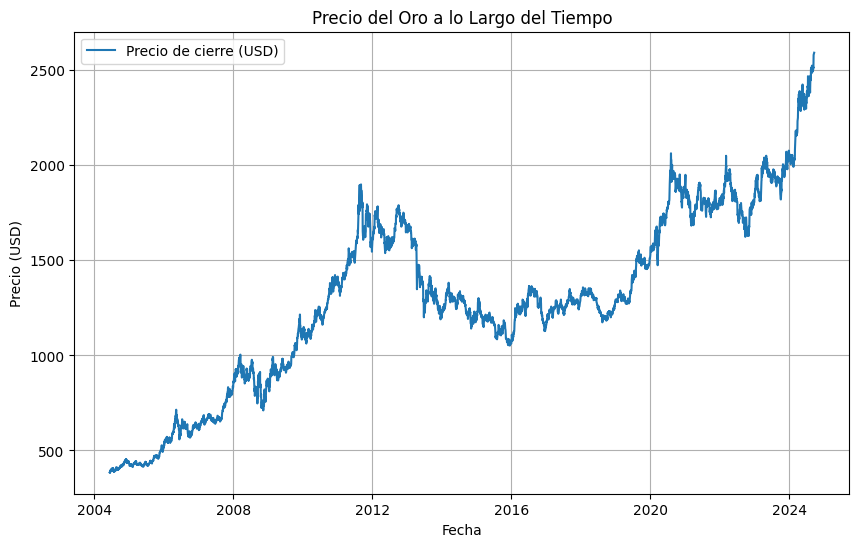

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(df.index, df['Close'], label='Precio de cierre (USD)')
plt.title('Precio del Oro a lo Largo del Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()


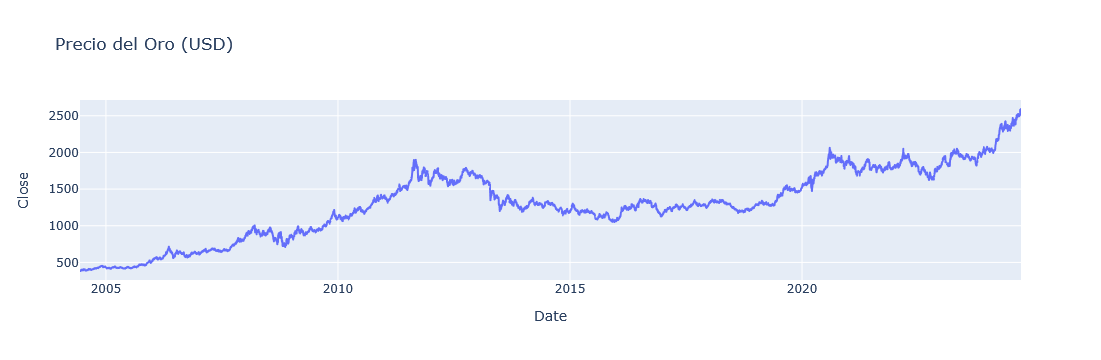

In [44]:
import plotly.express as px

fig = px.line(df, x=df.index, y='Close', title='Precio del Oro (USD)')
fig.show()


In [45]:
# Cargar el archivo CSV de eventos macroeconómicos
eventos_path = "C:\\Users\\Usuario\\Desktop\\TFFFG\\price-gold\\eventos_macroeconomicos.csv" 
eventos_df = pd.read_csv(eventos_path)

# Mostrar las primeras filas para verificar los datos
print(eventos_df.head())


        Fecha                                        Evento    Categoría
0  2008-09-15                    Quiebra de Lehman Brothers    Económico
1  2011-08-05  Rebaja de calificación crediticia de EE. UU.   Financiero
2  2020-03-11                   COVID-19 declarado pandemia        Salud
3  2022-02-24                 Invasión de Ucrania por Rusia  Geopolítico
4  2016-06-23                         Referéndum del Brexit     Político


In [46]:
eventos_df['Fecha'] = pd.to_datetime(eventos_df['Fecha'])


In [47]:
eventos_df = eventos_df.sort_values(by='Fecha')


In [48]:
print(eventos_df)


       Fecha                                            Evento  \
0 2008-09-15                        Quiebra de Lehman Brothers   
1 2011-08-05      Rebaja de calificación crediticia de EE. UU.   
5 2013-04-12  Caída abrupta del precio del oro (Crash del oro)   
4 2016-06-23                             Referéndum del Brexit   
2 2020-03-11                       COVID-19 declarado pandemia   
6 2021-01-20    Inauguración de Joe Biden y estímulos fiscales   
3 2022-02-24                     Invasión de Ucrania por Rusia   

            Categoría  
0           Económico  
1          Financiero  
5           Económico  
4            Político  
2               Salud  
6  Político/Económico  
3         Geopolítico  


In [49]:
# Definir el rango de fechas para el período de interés (Crisis de 2008)
inicio_crisis = "2008-01-01"
fin_crisis = "2009-12-31"

# Filtrar los datos para el rango definido
df_crisis = df[(df.index >= inicio_crisis) & (df.index <= fin_crisis)]

# Mostrar los datos filtrados
print(df_crisis.head())


             Time   Open   High    Low  Close  Volume
Date                                                 
2008-01-02  00:00  841.0  861.0  839.5  857.2    7298
2008-01-03  00:00  856.2  869.0  853.0  863.5   11609
2008-01-04  00:00  864.2  868.5  853.9  859.2   10650
2008-01-07  00:00  861.5  864.7  854.8  857.2    9230
2008-01-08  00:00  857.2  880.6  857.0  877.9   10093


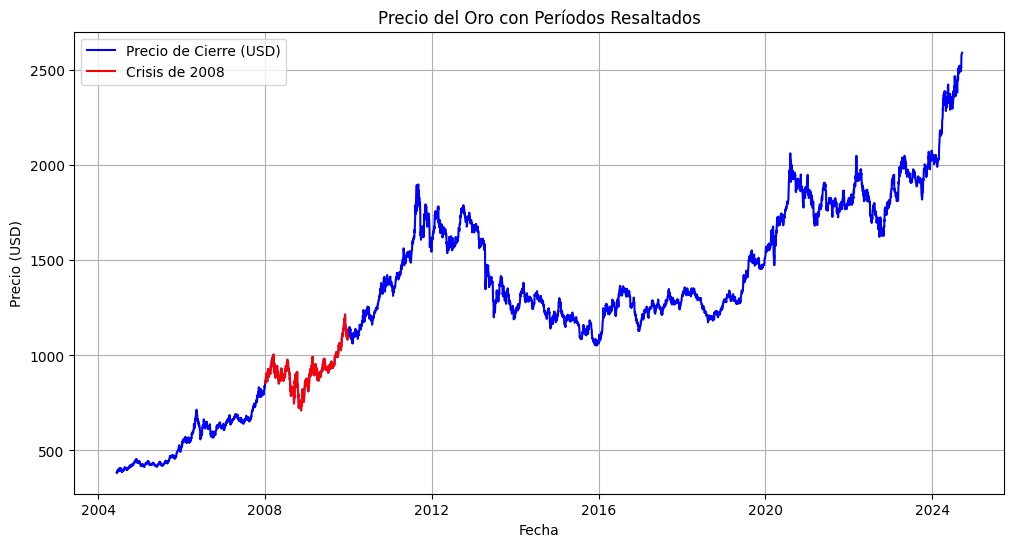

In [50]:
import matplotlib.pyplot as plt

# Graficar todos los datos del precio del oro
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Precio de Cierre (USD)', color='blue')

# Resaltar el período de la crisis de 2008
plt.plot(df_crisis.index, df_crisis['Close'], label='Crisis de 2008', color='red')

# Configuración del gráfico
plt.title('Precio del Oro con Períodos Resaltados')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()


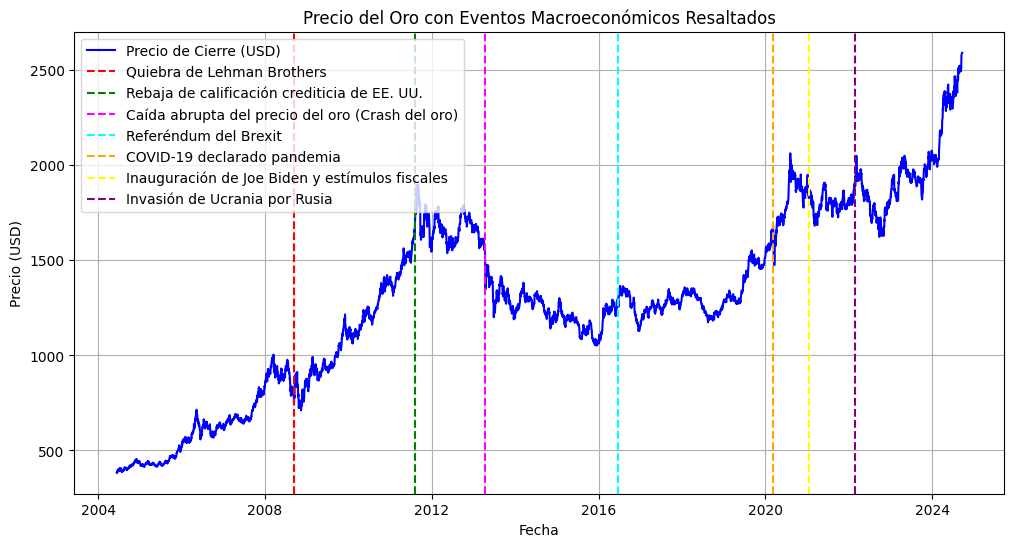

In [26]:
import matplotlib.pyplot as plt

# Crear una lista de colores para los eventos
colores = ['red', 'green', 'orange', 'purple', 'cyan', 'magenta', 'yellow']

# Graficar todos los datos del precio del oro
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Precio de Cierre (USD)', color='blue')

# Iterar sobre cada evento macroeconómico y resaltar el rango
for i, evento in eventos_df.iterrows():
    # Fecha del evento
    fecha_evento = evento['Fecha']
    nombre_evento = evento['Evento']
    
    # Graficar una línea vertical en la fecha del evento
    plt.axvline(x=fecha_evento, color=colores[i % len(colores)], linestyle='--', label=nombre_evento)

# Configuración del gráfico
plt.title('Precio del Oro con Eventos Macroeconómicos Resaltados')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid()
plt.show()


In [51]:
df['Cambio'] = df['Close'].pct_change()  # Variación porcentual diaria


In [52]:
df['Evento'] = df.index.isin(eventos_df['Fecha']).astype(int)  # Marca 1 si es un evento, 0 si no


In [53]:
correlacion = df[['Cambio', 'Evento']].corr().iloc[0, 1]
print(f"Correlación entre eventos y cambios en el precio del oro: {correlacion}")


Correlación entre eventos y cambios en el precio del oro: -0.006673301508424003


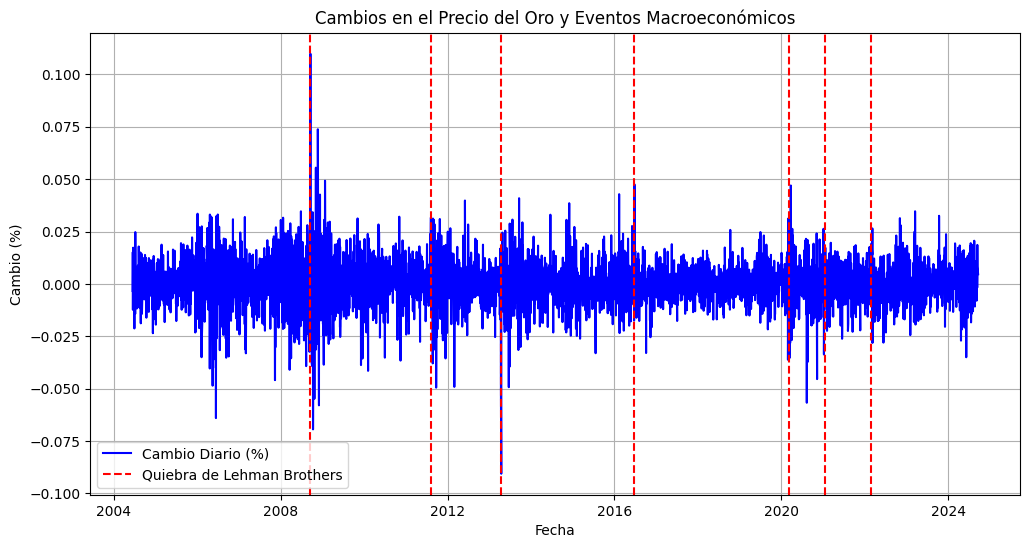

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cambio'], label='Cambio Diario (%)', color='blue')
for i, evento in eventos_df.iterrows():
    plt.axvline(x=evento['Fecha'], color='red', linestyle='--', label=evento['Evento'] if i == 0 else "")
plt.title('Cambios en el Precio del Oro y Eventos Macroeconómicos')
plt.xlabel('Fecha')
plt.ylabel('Cambio (%)')
plt.legend()
plt.grid()
plt.show()


In [55]:
# Inicializar un diccionario para almacenar las correlaciones
correlaciones = {}

# Iterar sobre cada evento macroeconómico
for i, evento in eventos_df.iterrows():
    # Fecha del evento
    fecha_evento = evento['Fecha']
    nombre_evento = evento['Evento']

    # Crear una columna temporal que marque 1 solo en la fecha del evento
    df[f'Evento_{i}'] = (df.index == fecha_evento).astype(int)

    # Calcular la correlación entre el evento y los cambios en el precio del oro
    correlacion = df[['Cambio', f'Evento_{i}']].corr().iloc[0, 1]

    # Guardar la correlación en el diccionario
    correlaciones[nombre_evento] = correlacion

# Mostrar las correlaciones calculadas para cada evento
for evento, correlacion in correlaciones.items():
    print(f"Correlación para {evento}: {correlacion}")



Correlación para Quiebra de Lehman Brothers: 0.03724952392083709
Correlación para Rebaja de calificación crediticia de EE. UU.: 0.013762670750933077
Correlación para Caída abrupta del precio del oro (Crash del oro): -0.06558758472726053
Correlación para Referéndum del Brexit: -0.010844715991294834
Correlación para COVID-19 declarado pandemia: -0.010517727442078503
Correlación para Inauguración de Joe Biden y estímulos fiscales: 0.02175577136130929
Correlación para Invasión de Ucrania por Rusia: -0.003463650930119413


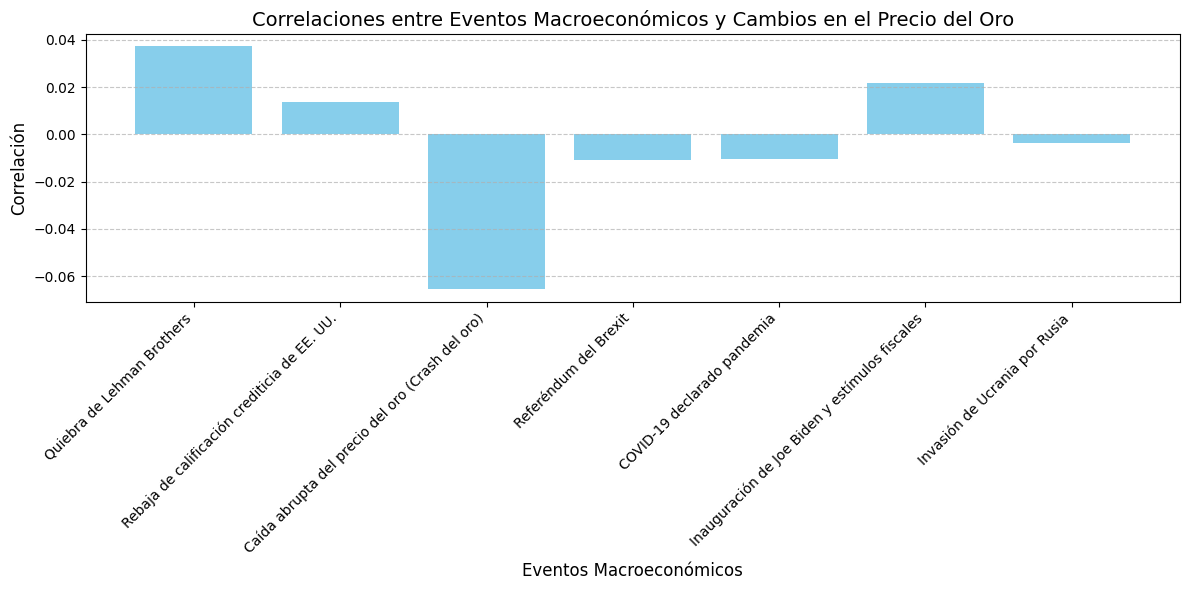

In [56]:
import matplotlib.pyplot as plt

# Extraer los nombres de los eventos y sus correlaciones
eventos = list(correlaciones.keys())
valores_correlacion = list(correlaciones.values())

# Crear el gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(eventos, valores_correlacion, color='skyblue')

# Configuración del gráfico
plt.title('Correlaciones entre Eventos Macroeconómicos y Cambios en el Precio del Oro', fontsize=14)
plt.xlabel('Eventos Macroeconómicos', fontsize=12)
plt.ylabel('Correlación', fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotar los nombres de los eventos para mejor visualización
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


                                             Evento      Fecha  \
0                        Quiebra de Lehman Brothers 2008-09-15   
1      Rebaja de calificación crediticia de EE. UU. 2011-08-05   
2  Caída abrupta del precio del oro (Crash del oro) 2013-04-12   
3                             Referéndum del Brexit 2016-06-23   
4                       COVID-19 declarado pandemia 2020-03-11   
5    Inauguración de Joe Biden y estímulos fiscales 2021-01-20   
6                     Invasión de Ucrania por Rusia 2022-02-24   

   Promedio Antes  Promedio Después  Cambio (%)  
0         768.380           852.720   10.976340  
1        1642.414          1750.990    6.610757  
2        1571.682          1376.816  -12.398564  
3        1280.058          1318.548    3.006895  
4        1661.778          1525.986   -8.171489  
5        1839.188          1855.134    0.867013  
6        1901.126          1921.182    1.054954  


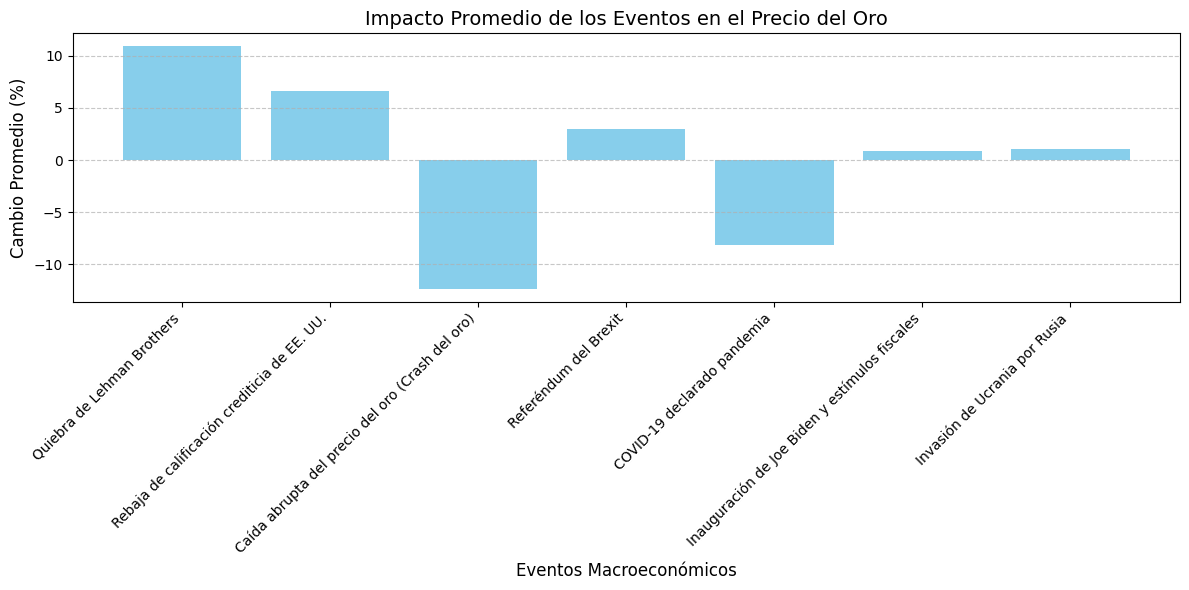

In [58]:
# Crear un DataFrame para almacenar los resultados
impacto_eventos = []

# Iterar sobre cada evento macroeconómico
for _, evento in eventos_df.iterrows():
    fecha_evento = evento['Fecha']
    nombre_evento = evento['Evento']
    
    # Rango de 7 días antes y después del evento
    rango_antes = df[(df.index >= fecha_evento - pd.Timedelta(days=7)) & (df.index < fecha_evento)]
    rango_despues = df[(df.index > fecha_evento) & (df.index <= fecha_evento + pd.Timedelta(days=7))]
    
    # Calcular los promedios
    precio_promedio_antes = rango_antes['Close'].mean()
    precio_promedio_despues = rango_despues['Close'].mean()
    
    # Calcular el cambio porcentual
    cambio_porcentual = ((precio_promedio_despues - precio_promedio_antes) / precio_promedio_antes) * 100
    
    # Guardar los resultados
    impacto_eventos.append({
        'Evento': nombre_evento,
        'Fecha': fecha_evento,
        'Promedio Antes': precio_promedio_antes,
        'Promedio Después': precio_promedio_despues,
        'Cambio (%)': cambio_porcentual
    })

# Convertir a DataFrame
impacto_eventos_df = pd.DataFrame(impacto_eventos)


# Mostrar la tabla de resultados
print(impacto_eventos_df)


# Graficar los cambios porcentuales
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.bar(impacto_eventos_df['Evento'], impacto_eventos_df['Cambio (%)'], color='skyblue')
plt.title('Impacto Promedio de los Eventos en el Precio del Oro', fontsize=14)
plt.xlabel('Eventos Macroeconómicos', fontsize=12)
plt.ylabel('Cambio Promedio (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


1
Evento_0    0
Evento_1    0
Evento_5    0
Evento_4    0
Evento_2    0
Evento_6    0
Evento_3    0
dtype: int64
Error Cuadrático Medio (MSE): 0.00011549343972815485
Coeficiente de Determinación (R²): -0.0007509443216817679
     Evento  Coeficiente
0  Evento_0     0.028799
1  Evento_1     0.010601
2  Evento_5    -0.050877
3  Evento_4    -0.008464
4  Evento_2    -0.008211
5  Evento_6     0.016794
6  Evento_3    -0.002745


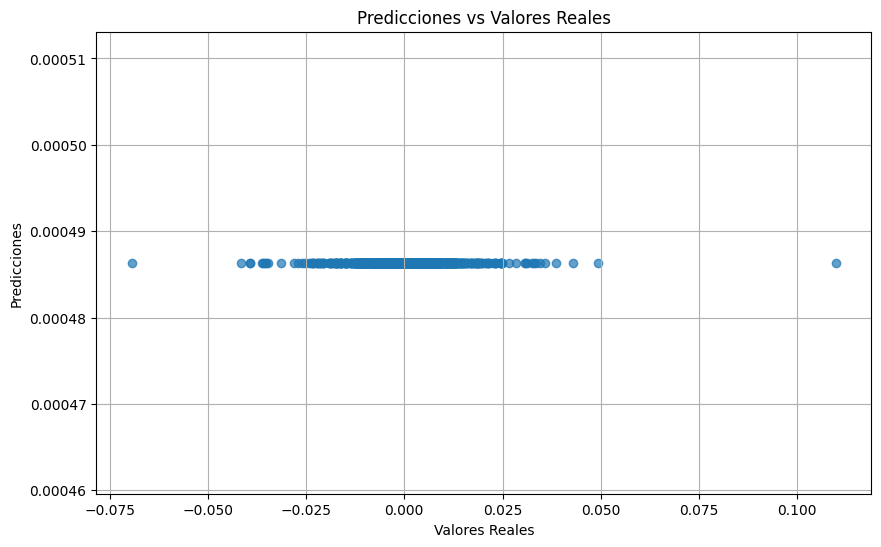

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Crear variables indicadoras para los eventos macroeconómicos
for i, evento in eventos_df.iterrows():
    fecha_evento = evento['Fecha']
    nombre_evento = evento['Evento']
    df[f'Evento_{i}'] = (df.index == fecha_evento).astype(int)

# Preparar las variables independientes (X) y dependiente (y)
X = df[[col for col in df.columns if col.startswith('Evento_')]]
y = df['Cambio']  # Cambios porcentuales diarios en el precio del oro

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
model = LinearRegression()

print(y_train.isnull().sum())
print(X_train.isnull().sum())

y_train = y_train.fillna(y_train.mean())
X_train = X_train.fillna(X_train.mean())



# Entrenar el modelo
model.fit(X_train, y_train)

# Hacer predicciones
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse}")
print(f"Coeficiente de Determinación (R²): {r2}")

# Mostrar los coeficientes del modelo
coeficientes = pd.DataFrame({
    'Evento': [col for col in X.columns],
    'Coeficiente': model.coef_
})
print(coeficientes)

# Graficar las predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.title('Predicciones vs Valores Reales')
plt.xlabel('Valores Reales')
plt.ylabel('Predicciones')
plt.grid()
plt.show()
